In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
from datetime import date

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_gdd_and_yield, \
    plot_yield_timeseries_residuals, plot_yearly_stresses
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameters_running_jablje import jablje_soil_layers, jablje_curve_number, \
    jablje_readily_evaporable_water, jablje_maize_params, jablje_management, jablje_initial_cond, \
    jablje_groundwater
from aquacrop_slovenia.diagnostics import print_metrics

In [38]:
# Set up working directory for outputs
output_dir = config.MODEL_RUNNING_DIR / "testing"
LOCATION = "jablje"

We exclude 2017 since we dont have ET data for most of the year

In [39]:
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
for year in range(1993, 2024) if year not in [2017]]

In [40]:
jablje_temperatures, jablje_eto, jablje_rain = get_station_weather(8) # Jablje uses ARSO meteo station 8 data

In [41]:
historical_co2 = get_co2_for_aquacrop("historical")

In [42]:
jablje_weather = Weather(
    location=LOCATION,
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [43]:
jablje_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=jablje_maize_params
)

In [44]:
jablje_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [45]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=jablje_management,
    initial_conditions=jablje_initial_cond,
    climate=jablje_weather,
    ground_water=jablje_groundwater,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [46]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: E:\aquacrop\testing
Running AquaCrop simulation with project file: E:\aquacrop\testing\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: E:\aquacrop\testing\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [47]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,1180.9,760.6,1135.1,355.97,0.0,738.3,...,45.0,6.943,7.715,2.12,0.0,0.0,31,12,1993,PROJECT.PRM
1,2,1,1,1994,1265.4,745.2,1207.5,357.58,0.0,851.7,...,50.5,10.078,11.198,2.42,0.0,0.0,31,12,1994,PROJECT.PRM
2,3,1,1,1995,1436.3,695.6,1017.1,359.53,0.0,877.7,...,51.2,7.430,8.255,2.13,0.0,0.0,31,12,1995,PROJECT.PRM
3,4,1,1,1996,1439.8,644.8,992.3,361.26,0.0,877.5,...,51.0,7.367,8.185,2.34,0.0,0.0,31,12,1996,PROJECT.PRM
4,5,1,1,1997,1144.1,725.2,1104.4,362.43,0.0,774.4,...,49.1,10.123,11.248,2.60,0.0,0.0,31,12,1997,PROJECT.PRM
5,6,1,1,1998,1347.8,709.7,1200.0,365.14,0.0,837.9,...,50.8,9.474,10.526,2.77,0.0,0.0,31,12,1998,PROJECT.PRM
6,7,1,1,1999,1390.5,679.8,1238.6,366.96,0.0,924.9,...,47.6,10.415,11.573,2.60,0.0,0.0,31,12,1999,PROJECT.PRM
7,8,1,1,2000,1439.3,747.8,1231.1,368.25,0.0,925.7,...,49.6,9.605,10.672,2.47,0.0,0.0,31,12,2000,PROJECT.PRM
8,9,1,1,2001,1169.9,699.8,1163.8,369.65,0.0,781.2,...,49.4,6.462,7.180,1.80,0.0,0.0,31,12,2001,PROJECT.PRM
9,10,1,1,2002,1176.9,689.4,1176.5,371.87,0.0,828.5,...,50.8,10.872,12.079,2.84,0.0,0.0,31,12,2002,PROJECT.PRM


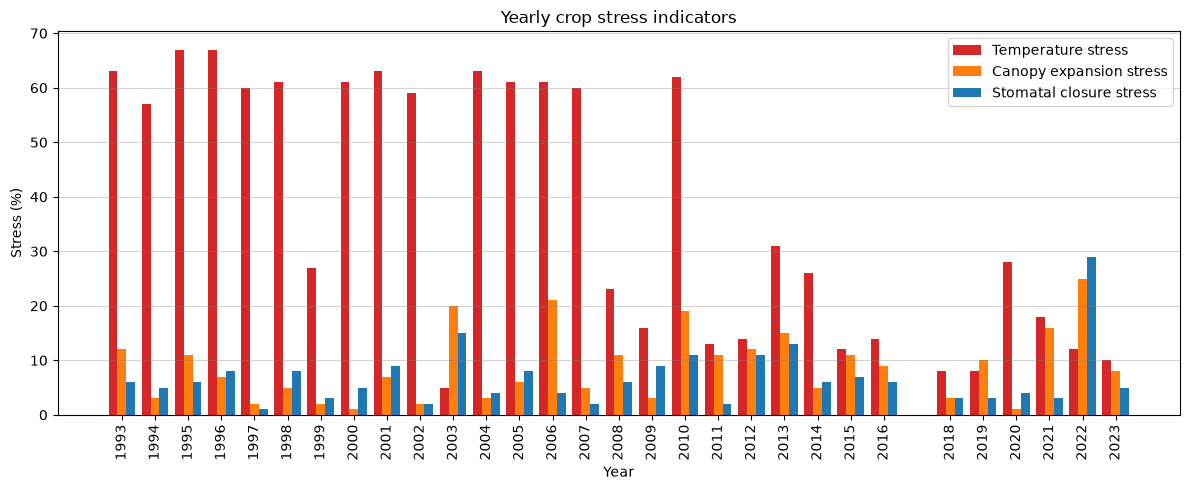

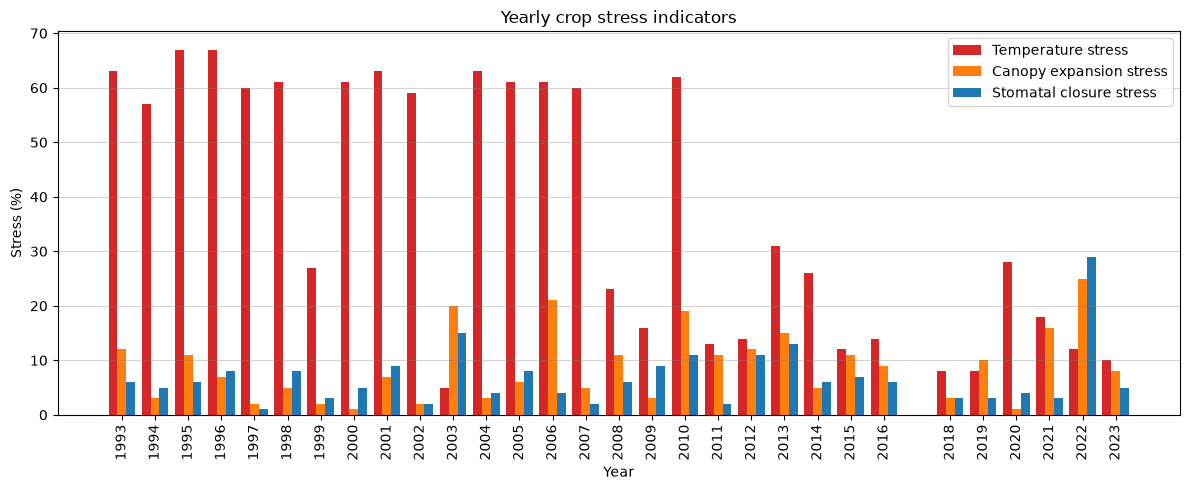

In [48]:
plot_yearly_stresses(seasonal_results)

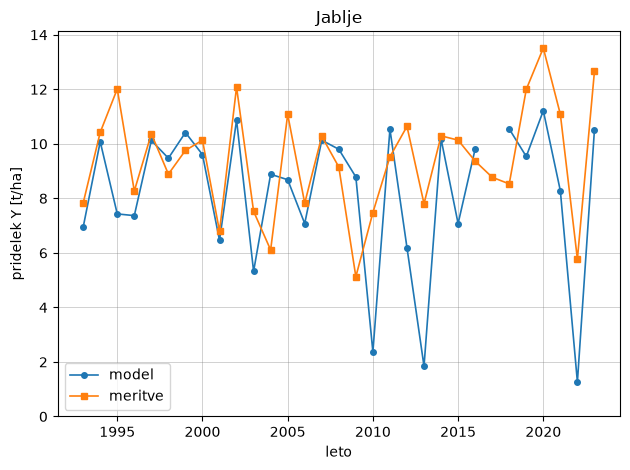

In [49]:
plot_yield_timeseries_comparison(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)

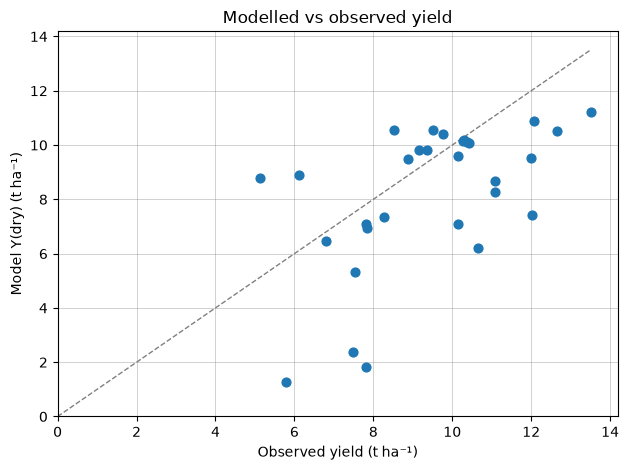

In [50]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"))

In [51]:
print_metrics(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)", "Grain")

=== Grain ===
  RMSE:       2.5712
  R2:         -0.5701
  NSE:        -0.5701
  KGE:        0.4537
  mKGE:       0.3394
  KGE_r:      0.5485
  KGE_beta:   0.8738
  KGE_alpha:  1.2805
  mKGE_alpha: 1.4654
  Willmott d: 0.6767
  Willmott dr:0.4157


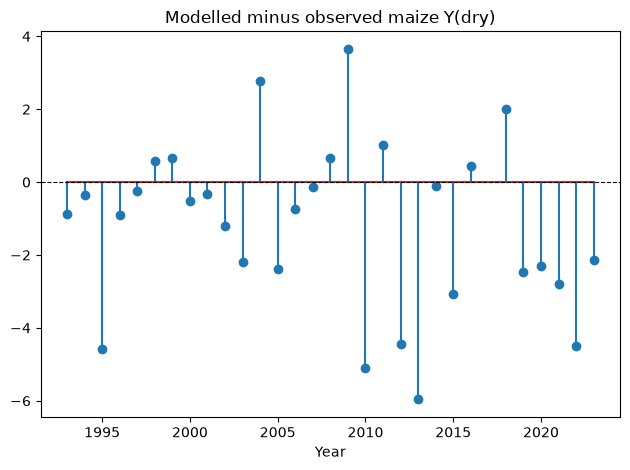

In [52]:
plot_yield_timeseries_residuals(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

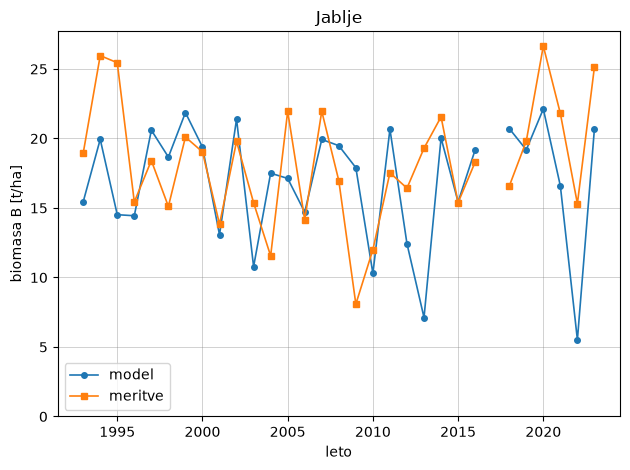

In [53]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass", LOCATION)

=== Biomass ===
  RMSE:       4.9696
  R2:         -0.3100
  NSE:        -0.3100
  KGE:        0.3801
  mKGE:       0.3771
  KGE_r:      0.3849
  KGE_beta:   0.9249
  KGE_alpha:  0.9835
  mKGE_alpha: 1.0634
  Willmott d: 0.5961
  Willmott dr:0.4507


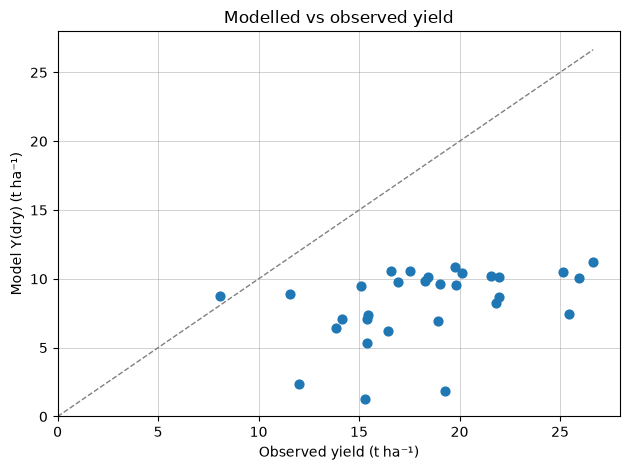

In [54]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "biomass", "A", "N3"))
print_metrics(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass", "Biomass")

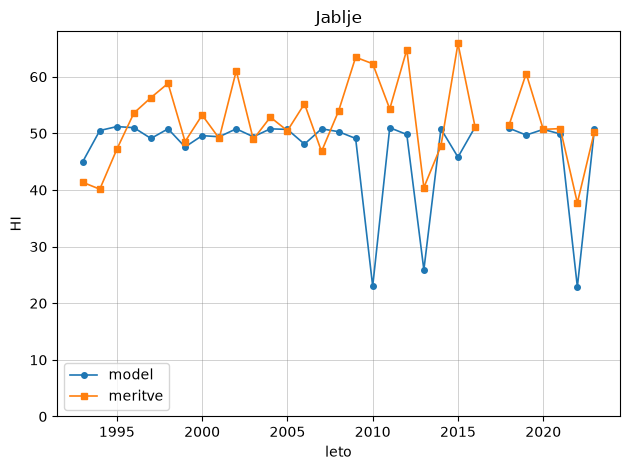

In [55]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "hi", "A", "N3"), "HI", LOCATION)

In [56]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(1.20),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,421.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,420.5,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,419.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,419.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,419.5,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,27,12,1993,239,4,441.5,6.0,0.0,0.0,4.9,...,None,None,None,None,None,None,None,None,None,None
361,28,12,1993,240,4,436.6,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
362,29,12,1993,241,4,432.5,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
363,30,12,1993,242,4,428.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

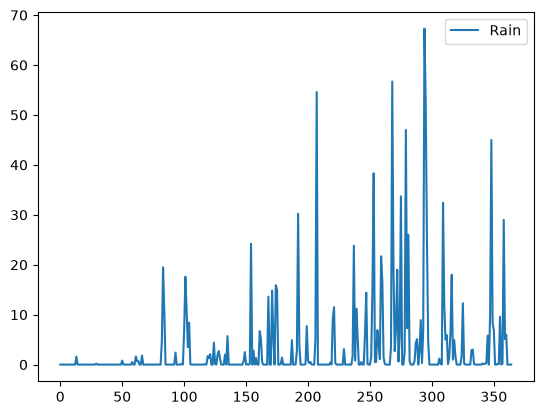

In [57]:
results["day"].plot(y="Rain")

<Axes: >

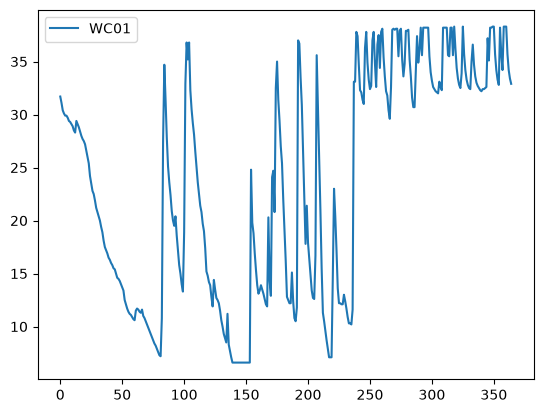

In [58]:
results["day"].plot(y="WC01")

In [59]:
#results["day"].plot(y="WC(2.30)")

<Axes: >

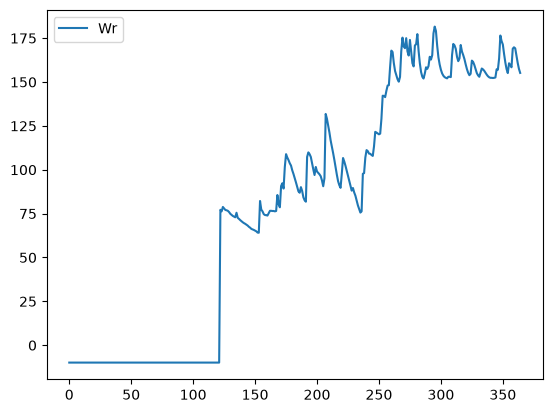

In [60]:
results["day"].plot(y="Wr")

<Axes: >

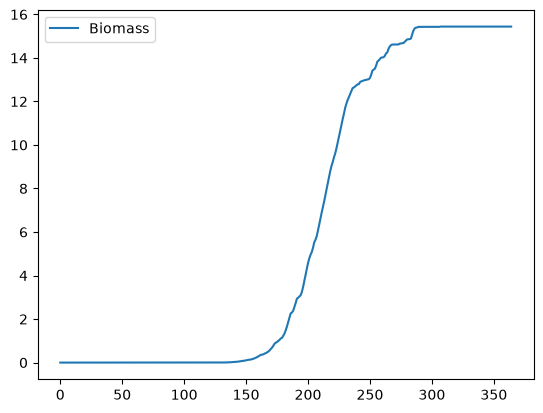

In [61]:
results["day"].plot(y="Biomass")

<Axes: >

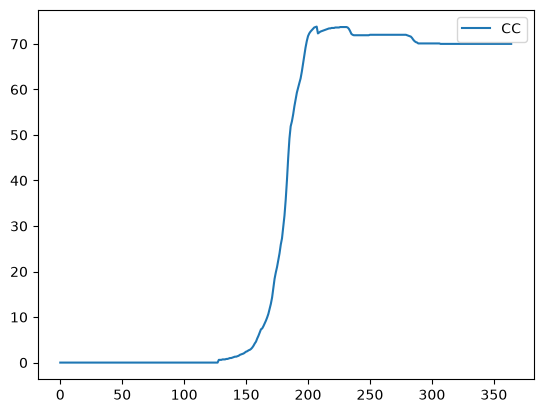

In [62]:
results["day"].plot(y="CC")

<Axes: >

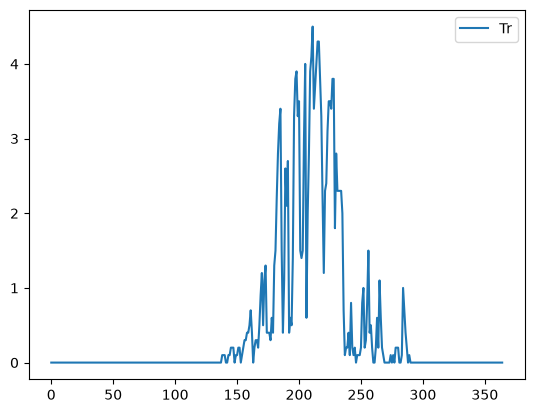

In [63]:
results["day"].plot(y="Tr")

<Axes: >

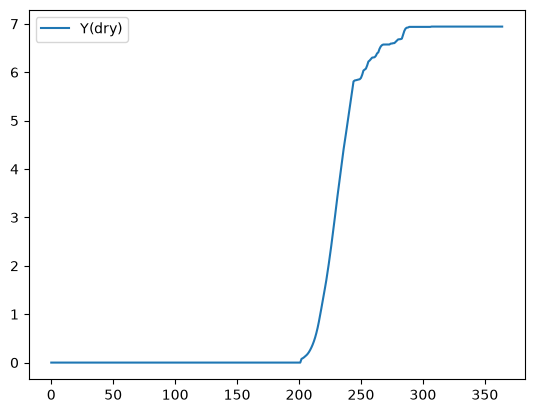

In [64]:
results["day"].plot(y="Y(dry)")

<Axes: >

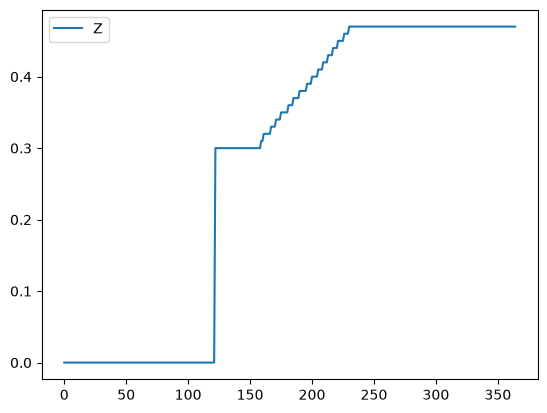

In [65]:
results["day"].plot(y="Z")

<Axes: >

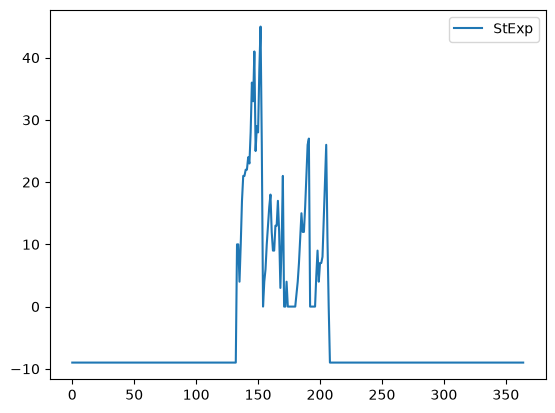

In [66]:
results["day"].plot(y="StExp")

<Axes: >

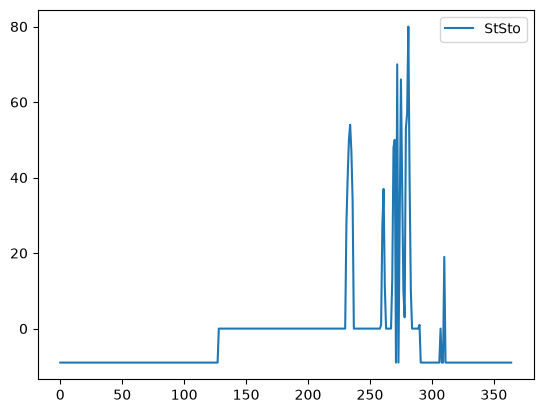

In [67]:
results["day"].plot(y="StSto")

<Axes: >

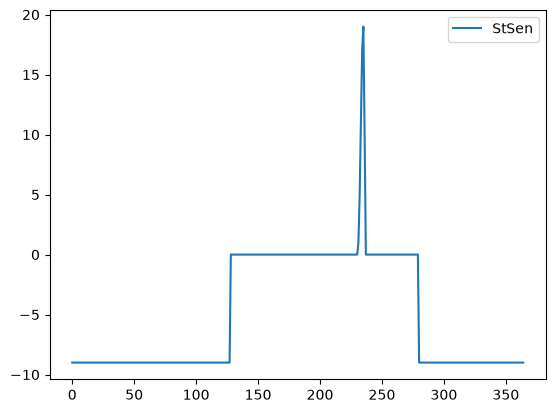

In [68]:
results["day"].plot(y="StSen")

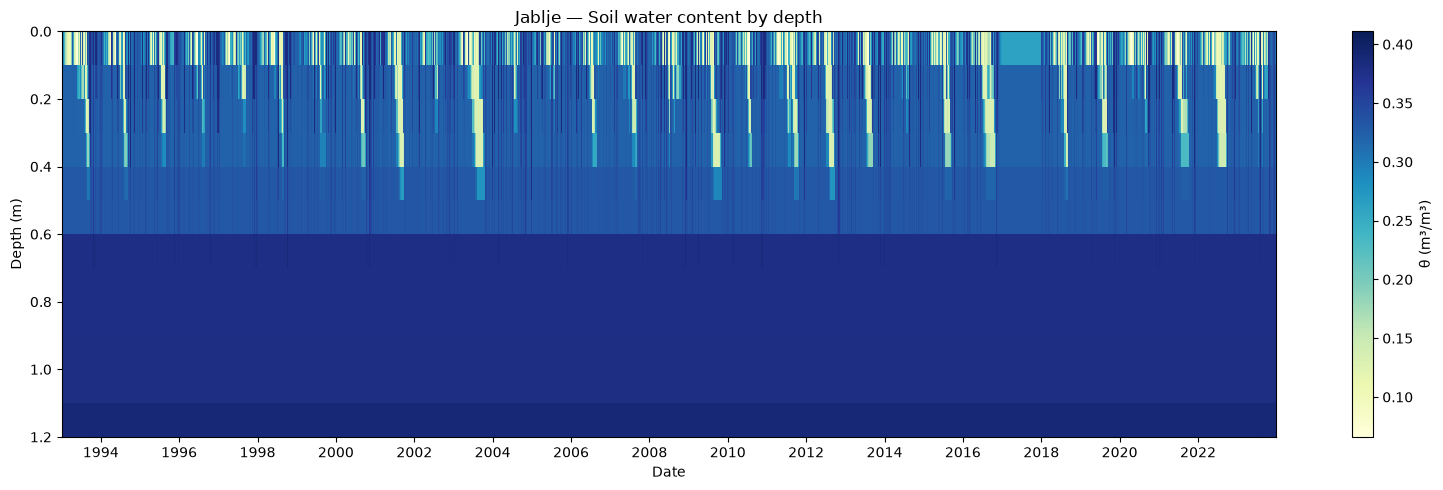

In [69]:
import pathlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from aquacrop.output import OutputReader

# Load daily output for all simulated years
reader = OutputReader(output_dir=str(output_dir / "OUTP"))
reader.scan_directory()

all_days = pd.concat(
    [reader.get_day_data(run_number=i) for i in range(1, len(simulation_periods) + 1)],
    ignore_index=True,
)
all_days.loc[:, "date"] = pd.to_datetime(dict(year=all_days["Year"], month=all_days["Month"], day=all_days["Day"]))

# AquaCrop writes "WC 2"–"WC 9" with spaces. The parser splits each into two tokens ("WC" + number),
# producing 8 extra column name slots. Data positions 69-80 (the 12 WC values) therefore land in
# alternating WC_N and bare-number columns. "WC_6"–"WC12" end up in the ECe section (all zeros).
wc_cols = ["WC01", "WC", "2", "WC_1", "3", "WC_2", "4", "WC_3", "5", "WC_4", "6", "WC_5"]

# Read compartment depth centres from the output file units row (line 5) at runtime.
# The units row lists depth [m] under each WC and ECe compartment; the first 12 numeric tokens
# are the WC compartment centres.
day_file = next(pathlib.Path(output_dir / "OUTP").glob("*day.OUT"))
with open(day_file) as f:
    units_line = f.readlines()[4]
numeric_units = []
for x in units_line.split():
    try:
        numeric_units.append(float(x))
    except ValueError:
        pass
centers = np.array(numeric_units[:12])

# Total soil depth from the WC(X.XX) column name
wc_total_col = next(c for c in all_days.columns if c.startswith("WC("))
total_depth = float(wc_total_col[3:-1])
bounds = np.concatenate([[0.0], (centers[:-1] + centers[1:]) / 2, [total_depth]])

# WC values are in vol%; convert to volumetric water content θ [m³/m³]
wc    = all_days[wc_cols].values.astype(float)   # (n_days, 12)
theta = wc / 100

# pcolormesh with shading='flat' needs (n+1) edges on both axes
dates   = mdates.date2num(all_days["date"].values)
x_edges = np.concatenate([[dates[0] - 0.5], dates + 0.5])

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.pcolormesh(x_edges, bounds, theta.T, cmap="YlGnBu", shading="flat")
ax.set_ylim(total_depth, 0)  # surface at top
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.colorbar(im, ax=ax, label="θ (m³/m³)")
ax.set_xlabel("Date")
ax.set_ylabel("Depth (m)")
ax.set_title("Jablje — Soil water content by depth")
plt.tight_layout()
plt.show()

<Axes: >

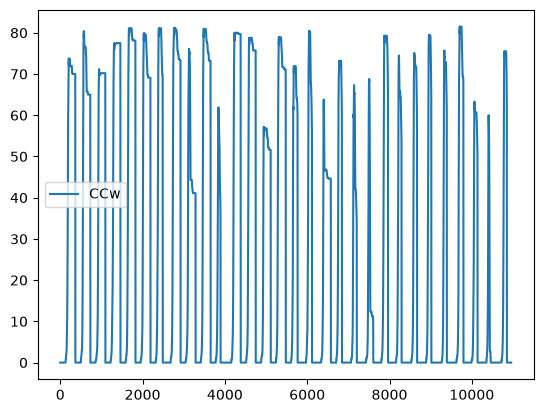

In [70]:
all_days.plot(y="CCw")